In [2]:
import pandas as pd

# Load CSV
df = pd.read_csv("../data/govuk_publications.csv")

# Basic information
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (468, 7)

Columns:
['title', 'description', 'url', 'author_organisation', 'published_date', 'updated_date', 'topic_url']

First 5 rows:
                                               title  \
0  Trusts and Estates: trustee notification of ta...   
1  Return of funds forfeited by the National Crim...   
2  Review of the economic requirement for UK trai...   
3  Process evaluation for the development of Lyme...   
4  Little Reckham Farm, screening decision, S37 C...   

                                         description  \
0  Use form R185 (Pension LSDB) to provide a bene...   
1  This agreement between the governments of the ...   
2  First phase of an independent review into trai...   
3  This project is a process evaluation for the d...   
4   Screening decision to reconductor approximate...   

                                                 url  \
0  https://www.gov.uk/government/publications/tru...   
1  https://www.gov.uk/government/publications/ret...   
2  https://www.

In [3]:
# Check descriptions containing HTML tags

html_rows = df[
    df["description"].fillna("").str.contains(
        r"<[^>]+>",
        regex=True
    )
]

print("Descriptions containing HTML:", len(html_rows))

print("\nExamples:")
print(
    html_rows["description"]
    .head(5)
    .to_string(index=False)
)

Descriptions containing HTML: 38

Examples:
<div class="govspeak"><p>The Department for Bus...
<div class="govspeak"><p>This document contains...
<div class="govspeak"><p>HM Treasury requires t...
<div class="govspeak"><p>This report shows inte...
<div class="govspeak"><p>The Ministry of Housin...


In [4]:
from bs4 import BeautifulSoup

def clean_html(text):
    if pd.isna(text):
        return text
    
    return BeautifulSoup(
        text,
        "html.parser"
    ).get_text(" ", strip=True)


df["description"] = df["description"].apply(clean_html)

In [5]:
html_rows_after = df[
    df["description"].fillna("").str.contains(
        r"<[^>]+>",
        regex=True
    )
]

print(
    "Descriptions containing HTML after cleaning:",
    len(html_rows_after)
)

Descriptions containing HTML after cleaning: 0


In [6]:
# Check missing and blank values

for column in df.columns:
    
    missing = df[column].isna().sum()
    
    blank = (
        df[column]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )
    
    print(
        column,
        "→ Missing:",
        missing,
        "| Blank:",
        blank
    )

title → Missing: 0 | Blank: 0
description → Missing: 146 | Blank: 146
url → Missing: 0 | Blank: 0
author_organisation → Missing: 0 | Blank: 0
published_date → Missing: 0 | Blank: 0
updated_date → Missing: 0 | Blank: 0
topic_url → Missing: 170 | Blank: 170


In [7]:
# Convert date columns to datetime

df["published_date"] = pd.to_datetime(
    df["published_date"],
    errors="coerce"
)

df["updated_date"] = pd.to_datetime(
    df["updated_date"],
    errors="coerce"
)


# Check datatypes

print(df.dtypes)

ValueError: Mixed timezones detected. Pass utc=True in to_datetime or tz='UTC' in DatetimeIndex to convert to a common timezone.

In [8]:
df["published_date"] = pd.to_datetime(
    df["published_date"],
    errors="coerce",
    utc=True
)

df["updated_date"] = pd.to_datetime(
    df["updated_date"],
    errors="coerce",
    utc=True
)

print(df.dtypes)

title                                  str
description                            str
url                                    str
author_organisation                    str
published_date         datetime64[us, UTC]
updated_date           datetime64[us, UTC]
topic_url                              str
dtype: object


In [9]:
print("\nMissing dates:")

print(
    df[
        ["published_date", "updated_date"]
    ].isna().sum()
)


Missing dates:
published_date    0
updated_date      0
dtype: int64


In [10]:
# Check duplicate rows

print("Duplicate complete rows:")
print(df.duplicated().sum())


# Check duplicate URLs

print("\nDuplicate URLs:")
print(df["url"].duplicated().sum())


# Check duplicate titles

print("\nDuplicate titles:")
print(df["title"].duplicated().sum())

Duplicate complete rows:
0

Duplicate URLs:
0

Duplicate titles:
0


In [11]:
text_columns = [
    "title",
    "description",
    "author_organisation"
]

for column in text_columns:

    leading_spaces = (
        df[column]
        .fillna("")
        .astype(str)
        .str.startswith(" ")
        .sum()
    )

    trailing_spaces = (
        df[column]
        .fillna("")
        .astype(str)
        .str.endswith(" ")
        .sum()
    )

    print(
        column,
        "→ Leading:", leading_spaces,
        "| Trailing:", trailing_spaces
    )

title → Leading: 0 | Trailing: 6
description → Leading: 0 | Trailing: 0
author_organisation → Leading: 0 | Trailing: 9


In [12]:
text_columns = [
    "title",
    "description",
    "author_organisation"
]

for column in text_columns:
    df[column] = df[column].str.strip()

In [13]:
for column in text_columns:

    leading_spaces = (
        df[column]
        .fillna("")
        .str.startswith(" ")
        .sum()
    )

    trailing_spaces = (
        df[column]
        .fillna("")
        .str.endswith(" ")
        .sum()
    )

    print(
        column,
        "→ Leading:", leading_spaces,
        "| Trailing:", trailing_spaces
    )

title → Leading: 0 | Trailing: 0
description → Leading: 0 | Trailing: 0
author_organisation → Leading: 0 | Trailing: 0


In [14]:
from urllib.parse import urlparse

def is_valid_url(url):
    if pd.isna(url):
        return False
    
    try:
        parsed = urlparse(str(url))
        
        return (
            parsed.scheme in ["http", "https"]
            and bool(parsed.netloc)
        )
        
    except:
        return False


print("Invalid publication URLs:",
      (~df["url"].apply(is_valid_url)).sum())

print("Invalid topic URLs:",
      (~df["topic_url"].apply(is_valid_url)).sum())

Invalid publication URLs: 0
Invalid topic URLs: 170


In [15]:
topic_urls = df["topic_url"].dropna()

invalid_topic_urls = (
    ~topic_urls.apply(is_valid_url)
).sum()

print("Available topic URLs:", len(topic_urls))
print("Invalid topic URLs:", invalid_topic_urls)

Available topic URLs: 298
Invalid topic URLs: 0


In [16]:
print("Number of unique organisations:",
      df["author_organisation"].nunique())

print("\nTop 15 organisations:")

print(
    df["author_organisation"]
    .value_counts()
    .head(15)
)

Number of unique organisations: 122

Top 15 organisations:
author_organisation
Home Office                                                           22
Department for Education                                              19
Foreign & Commonwealth Office                                         18
HM Revenue & Customs                                                  17
Department of Health and Social Care                                  17
Ministry of Defence                                                   14
Company Names Tribunal                                                14
Department for Work and Pensions                                      14
Marine Management Organisation                                        13
Department for Energy Security and Net Zero                           12
Ministry of Housing, Communities & Local Government (2018 to 2021)    12
Department for Transport                                              11
Public Health England                        

In [17]:
print("Minimum title length:",
      df["title"].str.len().min())

print("Maximum title length:",
      df["title"].str.len().max())

print("\nTitles with less than 5 characters:",
      (df["title"].str.len() < 5).sum())

print("\nEmpty titles:",
      df["title"].fillna("").str.strip().eq("").sum())

Minimum title length: 10
Maximum title length: 230

Titles with less than 5 characters: 0

Empty titles: 0


In [18]:
# Description length analysis

description_lengths = df["description"].dropna().str.len()

print("Descriptions available:",
      len(description_lengths))

print("Minimum description length:",
      description_lengths.min())

print("Maximum description length:",
      description_lengths.max())

print("Average description length:",
      round(description_lengths.mean(), 2))

print("\nDescriptions with less than 10 characters:",
      (description_lengths < 10).sum())

Descriptions available: 322
Minimum description length: 14
Maximum description length: 2377
Average description length: 146.23

Descriptions with less than 10 characters: 0


In [19]:
html_check = df[
    df["description"]
    .fillna("")
    .str.contains(r"<[^>]+>", regex=True)
]

print("HTML descriptions remaining:", len(html_check))

HTML descriptions remaining: 0


In [34]:
print("=" * 50)
print("FINAL DATA QUALITY REPORT")
print("=" * 50)

print("Total records:", len(df))
print("Total columns:", len(df.columns))

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate complete rows:", df.duplicated().sum())
print("Duplicate URLs:", df["url"].duplicated().sum())

print("\nUnique organisations:",
      df["author_organisation"].nunique())

print("\nHTML in descriptions:",
      df["description"]
      .fillna("")
      .str.contains(r"<[^>]+>", regex=True)
      .sum())

print("\nDate columns:")
print(df[["published_date", "updated_date"]].dtypes)

print("\nPublication URLs:")
print(
    (~df["url"].apply(is_valid_url)).sum(),
    "invalid"
)

FINAL DATA QUALITY REPORT
Total records: 468
Total columns: 9

Missing values:
title                    0
description            146
url                      0
author_organisation      0
published_date           0
updated_date             0
topic_url              170
published_year           0
description_length       0
dtype: int64

Duplicate complete rows: 0
Duplicate URLs: 0

Unique organisations: 122

HTML in descriptions: 0

Date columns:
published_date    datetime64[us, UTC]
updated_date      datetime64[us, UTC]
dtype: object

Publication URLs:
0 invalid


In [36]:
df.to_csv(
    "../data/govuk_publications_cleaned.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Cleaned CSV saved successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Cleaned CSV saved successfully.
Rows: 468
Columns: 9


In [37]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nNumerical Summary:")
print(df.describe())

Dataset Shape:
(468, 9)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 468 entries, 0 to 467
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   title                468 non-null    str                
 1   description          322 non-null    str                
 2   url                  468 non-null    str                
 3   author_organisation  468 non-null    str                
 4   published_date       468 non-null    datetime64[us, UTC]
 5   updated_date         468 non-null    datetime64[us, UTC]
 6   topic_url            298 non-null    str                
 7   published_year       468 non-null    int32              
 8   description_length   468 non-null    int64              
dtypes: datetime64[us, UTC](2), int32(1), int64(1), str(5)
memory usage: 189.2 KB
None

Numerical Summary:
       published_year  description_length
count      468.000000         

In [38]:
df["published_year"] = df["published_date"].dt.year

year_counts = (
    df["published_year"]
    .value_counts()
    .sort_index()
)

print(year_counts)

published_year
1975     1
1981     1
2000     1
2004     4
2005     1
2006     3
2007     1
2008     2
2009     5
2010     9
2011    17
2012    22
2013    22
2014    33
2015    23
2016    26
2017    25
2018    20
2019    12
2020    23
2021    34
2022    43
2023    26
2024    44
2025    47
2026    23
Name: count, dtype: int64


In [39]:
print("\nTop 10 publication years:")

print(
    df["published_year"]
    .value_counts()
    .head(10)
)


Top 10 publication years:
published_year
2025    47
2024    44
2022    43
2021    34
2014    33
2023    26
2016    26
2017    25
2026    23
2020    23
Name: count, dtype: int64


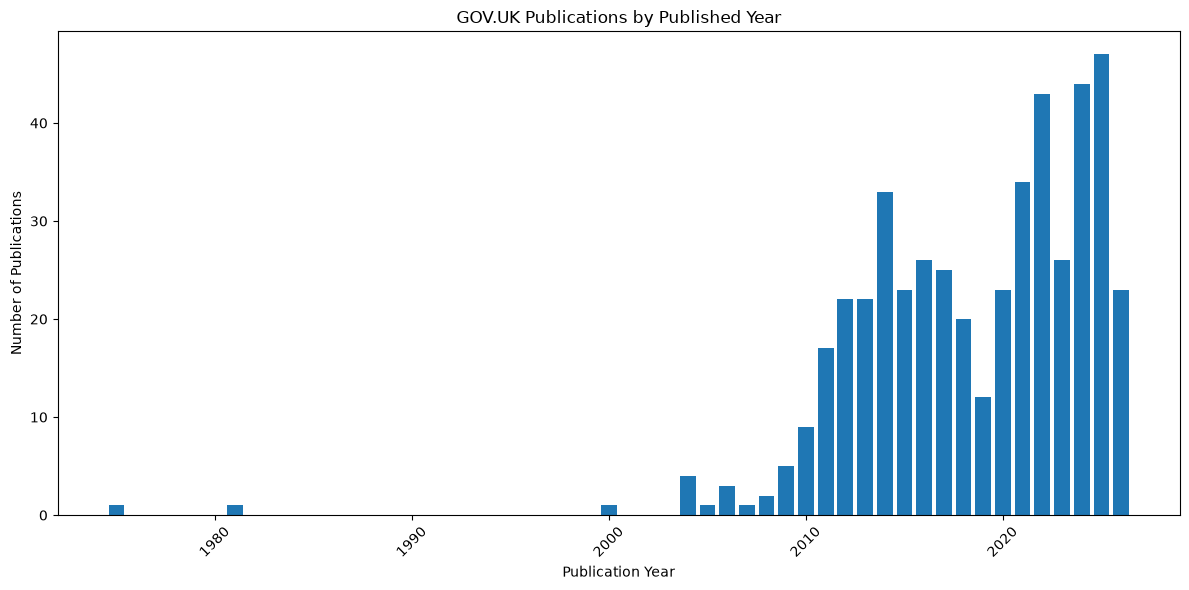

In [40]:
import matplotlib.pyplot as plt

year_counts = (
    df["published_year"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 6))

plt.bar(
    year_counts.index,
    year_counts.values
)

plt.xlabel("Publication Year")
plt.ylabel("Number of Publications")
plt.title("GOV.UK Publications by Published Year")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [41]:
org_counts = (
    df["author_organisation"]
    .value_counts()
    .head(15)
)

print(org_counts)

author_organisation
Home Office                                                           22
Department for Education                                              19
Foreign & Commonwealth Office                                         18
HM Revenue & Customs                                                  17
Department of Health and Social Care                                  17
Ministry of Defence                                                   14
Company Names Tribunal                                                14
Department for Work and Pensions                                      14
Marine Management Organisation                                        13
Department for Energy Security and Net Zero                           12
Ministry of Housing, Communities & Local Government (2018 to 2021)    12
Department for Transport                                              11
Public Health England                                                 11
Department for Business, Innova

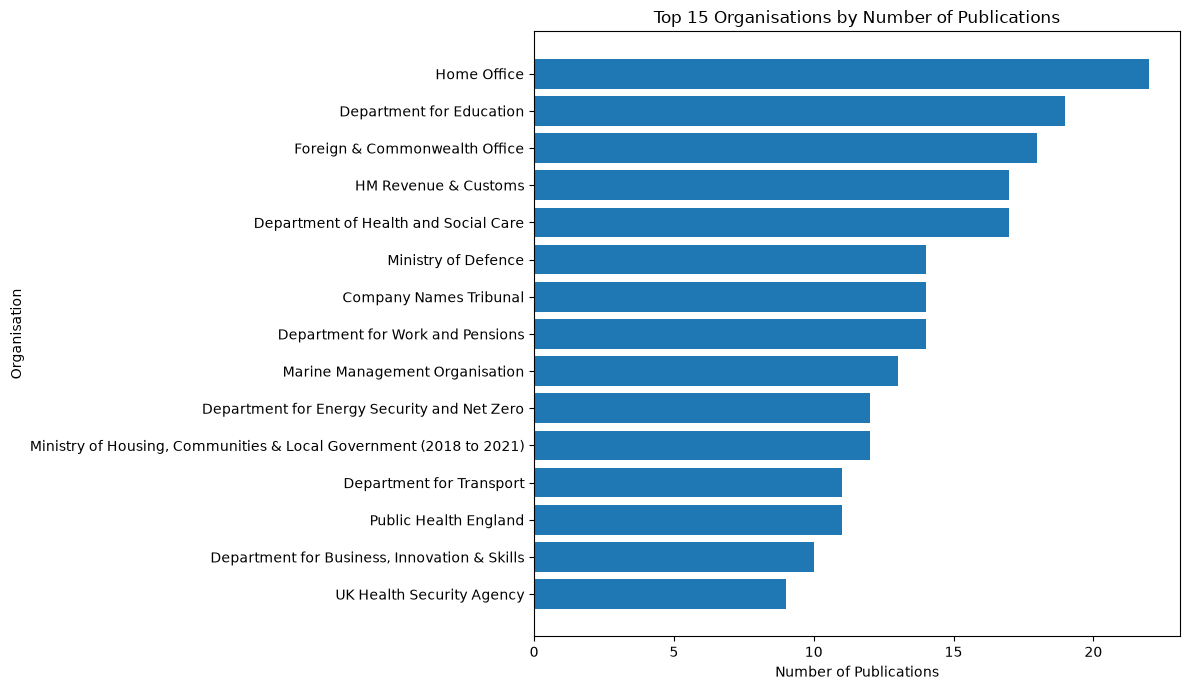

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

plt.barh(
    org_counts.index[::-1],
    org_counts.values[::-1]
)

plt.xlabel("Number of Publications")
plt.ylabel("Organisation")
plt.title("Top 15 Organisations by Number of Publications")

plt.tight_layout()
plt.show()

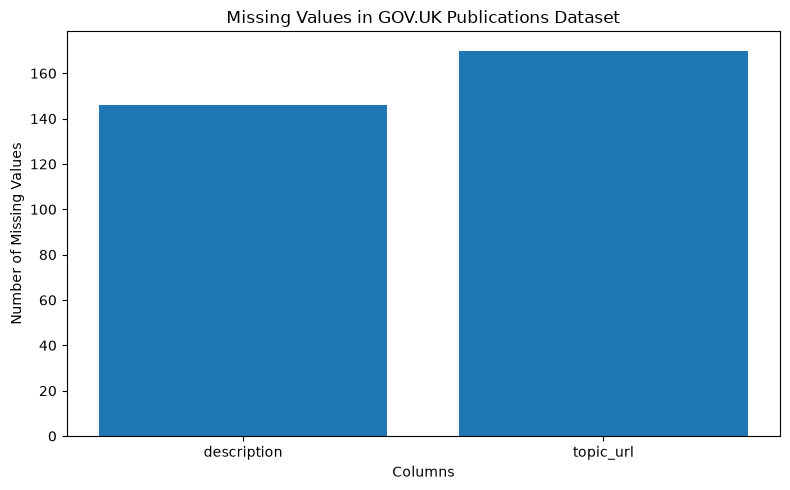

In [43]:
missing = df.isna().sum()

missing = missing[missing > 0]

plt.figure(figsize=(8, 5))

plt.bar(
    missing.index,
    missing.values
)

plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.title("Missing Values in GOV.UK Publications Dataset")

plt.tight_layout()
plt.show()

In [44]:
# Description length

df["description_length"] = (
    df["description"]
    .fillna("")
    .str.len()
)

print("Description length statistics:")

print(
    df["description_length"].describe()
)

Description length statistics:
count     468.000000
mean      100.613248
std       170.795851
min         0.000000
25%         0.000000
50%        86.000000
75%       129.250000
max      2377.000000
Name: description_length, dtype: float64


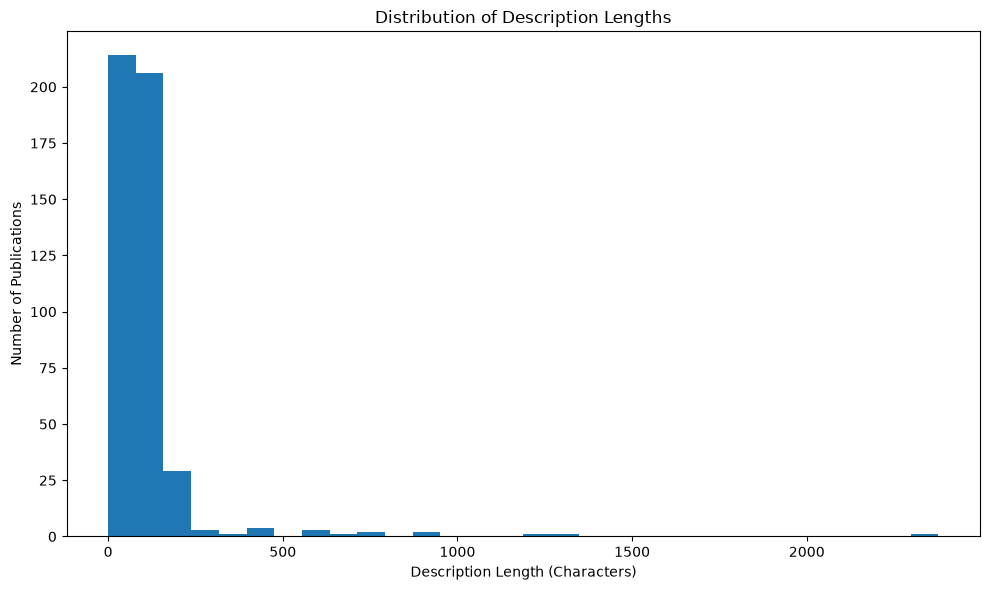

In [45]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["description_length"],
    bins=30
)

plt.xlabel("Description Length (Characters)")
plt.ylabel("Number of Publications")
plt.title("Distribution of Description Lengths")

plt.tight_layout()
plt.show()

In [46]:
topic_counts = (
    df["topic_url"]
    .dropna()
    .value_counts()
    .head(15)
)

print("Top 15 Topics:")
print(topic_counts)

Top 15 Topics:
topic_url
https://www.gov.uk/government/government-efficiency-transparency-and-accountability    38
https://www.gov.uk/health-and-social-care/national-health-service                      11
https://www.gov.uk/defence-and-armed-forces                                             9
https://www.gov.uk/corporate-information                                                8
https://www.gov.uk/government/government-spending                                       8
https://www.gov.uk/business-and-industry/trade-and-investment                           5
https://www.gov.uk/crime-justice-and-law                                                5
https://www.gov.uk/business-and-industry                                                5
https://www.gov.uk/environment/climate-change-energy                                    4
https://www.gov.uk/work                                                                 4
https://www.gov.uk/crime-justice-and-law/courts-sentencing-tribunals       

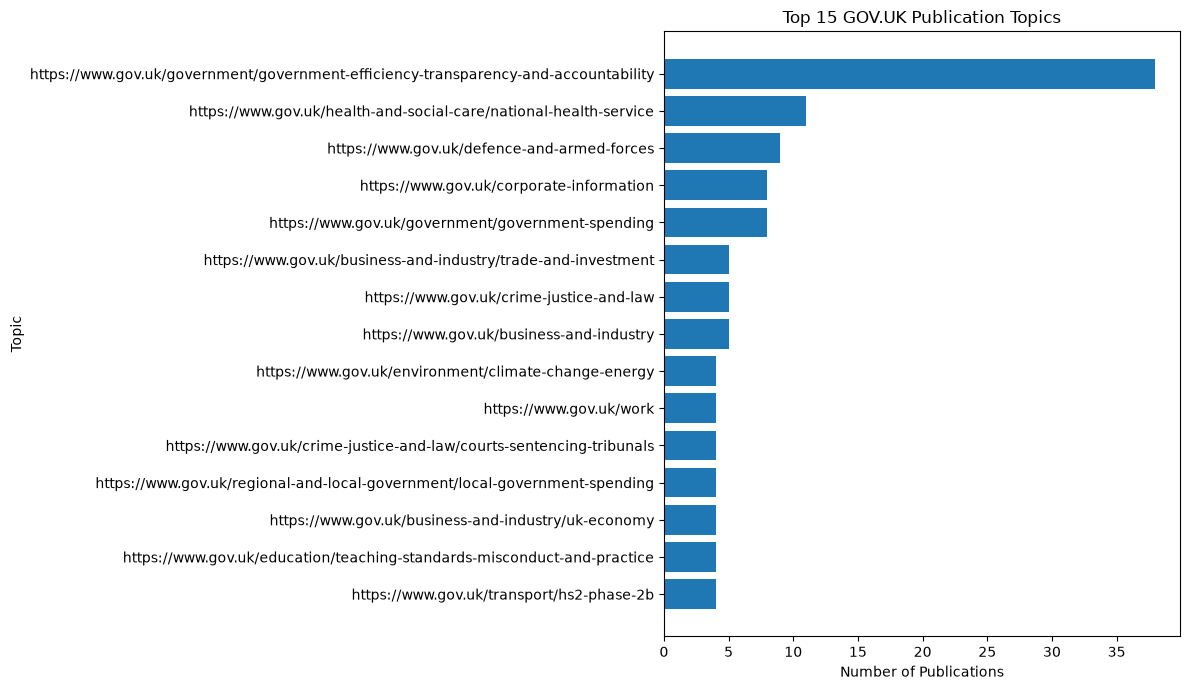

In [47]:
plt.figure(figsize=(12, 7))

plt.barh(
    topic_counts.index[::-1],
    topic_counts.values[::-1]
)

plt.xlabel("Number of Publications")
plt.ylabel("Topic")
plt.title("Top 15 GOV.UK Publication Topics")

plt.tight_layout()
plt.show()

In [48]:
year_org = pd.crosstab(
    df["published_date"].dt.year,
    df["author_organisation"]
)

print(year_org.shape)
print(year_org.head())

(26, 122)
author_organisation  Active Travel England  \
published_date                               
1975                                     0   
1981                                     0   
2000                                     0   
2004                                     0   
2005                                     0   

author_organisation  Advisory Committee on Business Appointments  \
published_date                                                     
1975                                                           0   
1981                                                           0   
2000                                                           0   
2004                                                           0   
2005                                                           0   

author_organisation  Advisory Committee on Clinical Impact Awards  \
published_date                                                      
1975                                                

In [49]:
top_orgs = (
    df["author_organisation"]
    .value_counts()
    .head(10)
    .index
)

year_org_top = pd.crosstab(
    df["published_date"].dt.year,
    df["author_organisation"]
)[top_orgs]

print(year_org_top)

author_organisation  Home Office  Department for Education  \
published_date                                               
1975                           0                         0   
1981                           0                         0   
2000                           0                         0   
2004                           0                         0   
2005                           0                         0   
2006                           0                         0   
2007                           0                         0   
2008                           0                         0   
2009                           1                         0   
2010                           0                         0   
2011                           1                         0   
2012                           1                         0   
2013                           3                         1   
2014                           1                         0   
2015    

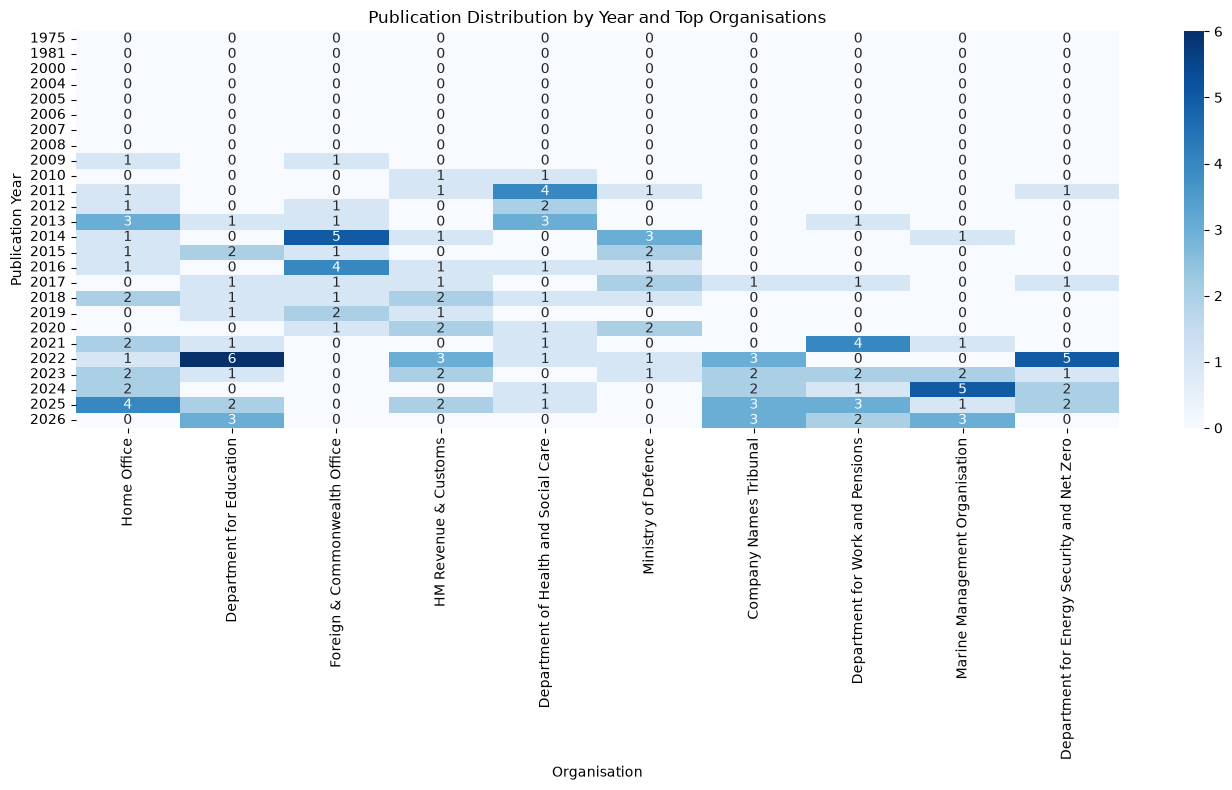

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

sns.heatmap(
    year_org_top,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Organisation")
plt.ylabel("Publication Year")
plt.title("Publication Distribution by Year and Top Organisations")

plt.tight_layout()
plt.show()

In [51]:
# -----------------------------------
# DATE-BASED FEATURE ENGINEERING
# -----------------------------------

df["published_year"] = df["published_date"].dt.year
df["published_month"] = df["published_date"].dt.month
df["published_quarter"] = df["published_date"].dt.quarter
df["published_dayofweek"] = df["published_date"].dt.dayofweek

# Days between publication and last update
df["days_to_update"] = (
    df["updated_date"] - df["published_date"]
).dt.days

print(df[
    [
        "published_date",
        "published_year",
        "published_month",
        "published_quarter",
        "published_dayofweek",
        "days_to_update"
    ]
].head())

             published_date  published_year  published_month  \
0 2017-04-05 23:15:00+00:00            2017                4   
1 2021-09-22 14:29:00+00:00            2021                9   
2 2012-01-23 00:00:00+00:00            2012                1   
3 2024-04-10 23:00:00+00:00            2024                4   
4 2024-01-25 00:00:00+00:00            2024                1   

   published_quarter  published_dayofweek  days_to_update  
0                  2                    2              20  
1                  3                    2               0  
2                  1                    0               0  
3                  2                    2             189  
4                  1                    3               0  


In [52]:
# -----------------------------------
# TEXT FEATURE ENGINEERING
# -----------------------------------

# Title features
df["title_length"] = df["title"].str.len()
df["title_word_count"] = df["title"].str.split().str.len()

# Description features
df["description_length"] = df["description"].str.len()
df["description_word_count"] = (
    df["description"]
    .fillna("")
    .str.split()
    .str.len()
)

# Combined text
df["text_length"] = (
    df["title_length"] +
    df["description_length"]
)

df["text_word_count"] = (
    df["title_word_count"] +
    df["description_word_count"]
)

print(df[
    [
        "title",
        "title_length",
        "title_word_count",
        "description_length",
        "description_word_count",
        "text_length",
        "text_word_count"
    ]
].head())

                                               title  title_length  \
0  Trusts and Estates: trustee notification of ta...            70   
1  Return of funds forfeited by the National Crim...           101   
2  Review of the economic requirement for UK trai...            59   
3  Process evaluation for the development of Lyme...            90   
4  Little Reckham Farm, screening decision, S37 C...            74   

   title_word_count  description_length  description_word_count  text_length  \
0                10               125.0                      21        195.0   
1                16               140.0                      24        241.0   
2                 9                99.0                      15        158.0   
3                12               196.0                      30        286.0   
4                10               140.0                      21        214.0   

   text_word_count  
0               31  
1               40  
2               24  
3             

In [53]:
# -----------------------------------
# ORGANISATION & TOPIC FEATURES
# -----------------------------------

# Organisation name length
df["organisation_length"] = (
    df["author_organisation"].str.len()
)

# Number of words in organisation name
df["organisation_word_count"] = (
    df["author_organisation"]
    .str.split()
    .str.len()
)

# Topic available or not
df["has_topic"] = (
    df["topic_url"].notna()
).astype(int)

# Topic category from URL
df["topic_category"] = (
    df["topic_url"]
    .fillna("")
    .str.replace("https://www.gov.uk/", "", regex=False)
    .str.split("/")
    .str[0]
)

print(df[
    [
        "author_organisation",
        "organisation_length",
        "organisation_word_count",
        "topic_url",
        "has_topic",
        "topic_category"
    ]
].head())

                           author_organisation  organisation_length  \
0                         HM Revenue & Customs                   20   
1                                  Home Office                   11   
2                     Department for Transport                   24   
3               Marine Management Organisation                   30   
4  Department for Energy Security and Net Zero                   43   

   organisation_word_count                                          topic_url  \
0                        4                    https://www.gov.uk/money/trusts   
1                        2   https://www.gov.uk/international/anti-corruption   
2                        3  https://www.gov.uk/transport/ship-crew-trainin...   
3                        3  https://www.gov.uk/environment/environmental-m...   
4                        7  https://www.gov.uk/business-and-industry/energ...   

   has_topic         topic_category  
0          1                  money  
1         

In [54]:
# -----------------------------------
# CREATE TARGET VARIABLE
# -----------------------------------

# Median update time
median_days = df["days_to_update"].median()

print("Median days to update:", median_days)

# 1 = took longer than typical to update
# 0 = took typical/less time
df["high_update_time"] = (
    df["days_to_update"] > median_days
).astype(int)

print("\nTarget distribution:")
print(df["high_update_time"].value_counts())

print("\nTarget percentage:")
print(
    df["high_update_time"]
    .value_counts(normalize=True) * 100
)

Median days to update: 0.0

Target distribution:
high_update_time
0    336
1    132
Name: count, dtype: int64

Target percentage:
high_update_time
0    71.794872
1    28.205128
Name: proportion, dtype: float64


In [55]:
print("Target distribution:")
print(df["high_update_time"].value_counts())

print("\nTarget distribution (%):")
print(
    df["high_update_time"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target distribution:
high_update_time
0    336
1    132
Name: count, dtype: int64

Target distribution (%):
high_update_time
0    71.79
1    28.21
Name: proportion, dtype: float64


In [56]:
from sklearn.model_selection import train_test_split

# Target
y = df["high_update_time"]

# Features
X = df.drop(
    columns=[
        "high_update_time",
        "days_to_update"
    ]
)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (374, 21)
Testing data: (94, 21)

Training target distribution:
high_update_time
0    269
1    105
Name: count, dtype: int64

Testing target distribution:
high_update_time
0    67
1    27
Name: count, dtype: int64


In [57]:
print("Missing values in text features:")

print(
    X_train[
        ["title", "description"]
    ].isna().sum()
)

Missing values in text features:
title            0
description    117
dtype: int64


In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Missing descriptions → empty text
train_title = X_train["title"].fillna("")
train_description = X_train["description"].fillna("")

test_title = X_test["title"].fillna("")
test_description = X_test["description"].fillna("")


# -----------------------------------
# TITLE TF-IDF
# -----------------------------------

title_vectorizer = TfidfVectorizer(
    max_features=500,
    stop_words="english"
)

X_train_title_tfidf = title_vectorizer.fit_transform(
    train_title
)

X_test_title_tfidf = title_vectorizer.transform(
    test_title
)


# -----------------------------------
# DESCRIPTION TF-IDF
# -----------------------------------

description_vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words="english"
)

X_train_description_tfidf = description_vectorizer.fit_transform(
    train_description
)

X_test_description_tfidf = description_vectorizer.transform(
    test_description
)


print("Title TF-IDF:")
print("Train:", X_train_title_tfidf.shape)
print("Test :", X_test_title_tfidf.shape)

print("\nDescription TF-IDF:")
print("Train:", X_train_description_tfidf.shape)
print("Test :", X_test_description_tfidf.shape)

Title TF-IDF:
Train: (374, 500)
Test : (94, 500)

Description TF-IDF:
Train: (374, 1000)
Test : (94, 1000)


In [59]:
numerical_features = [
    "published_year",
    "published_month",
    "published_quarter",
    "published_dayofweek",
    "title_length",
    "title_word_count",
    "description_length",
    "description_word_count",
    "text_length",
    "text_word_count",
    "organisation_length",
    "organisation_word_count",
    "has_topic"
]

In [60]:
categorical_features = [
    "author_organisation",
    "topic_category"
]

In [62]:
# Missing text values ko empty string se replace karo

X_train = X_train.copy()
X_test = X_test.copy()

X_train["title"] = X_train["title"].fillna("")
X_train["description"] = X_train["description"].fillna("")

X_test["title"] = X_test["title"].fillna("")
X_test["description"] = X_test["description"].fillna("")

In [63]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer


# -----------------------------------
# NUMERICAL FEATURES
# -----------------------------------

numerical_features = [
    "published_year",
    "published_month",
    "published_quarter",
    "published_dayofweek",
    "title_length",
    "title_word_count",
    "description_length",
    "description_word_count",
    "text_length",
    "text_word_count",
    "organisation_length",
    "organisation_word_count",
    "has_topic"
]


# -----------------------------------
# CATEGORICAL FEATURES
# -----------------------------------

categorical_features = [
    "author_organisation",
    "topic_category"
]


# -----------------------------------
# NUMERICAL PIPELINE
# -----------------------------------

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# -----------------------------------
# CATEGORICAL PIPELINE
# -----------------------------------

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore"
    ))
])


# -----------------------------------
# COMPLETE PREPROCESSOR
# -----------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        
        # Title text
        (
            "title_tfidf",
            TfidfVectorizer(
                max_features=500,
                stop_words="english"
            ),
            "title"
        ),
        
        # Description text
        (
            "description_tfidf",
            TfidfVectorizer(
                max_features=1000,
                stop_words="english"
            ),
            "description"
        ),
        
        # Numerical
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        
        # Categorical
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)


# -----------------------------------
# FIT ON TRAINING DATA ONLY
# -----------------------------------

X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)


print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (374, 1646)
Processed testing shape: (94, 1646)


In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# -----------------------------------
# BASELINE LOGISTIC REGRESSION
# -----------------------------------

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(
    X_train_processed,
    y_train
)


# Prediction
y_pred = baseline_model.predict(
    X_test_processed
)

y_prob = baseline_model.predict_proba(
    X_test_processed
)[:, 1]


# Metrics
print("Baseline Logistic Regression")
print("--------------------------------")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Baseline Logistic Regression
--------------------------------
Accuracy : 0.7021276595744681
Precision: 0.47368421052631576
Recall   : 0.3333333333333333
F1 Score : 0.391304347826087
ROC-AUC  : 0.6854615809839689


In [65]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# -----------------------------------
# SVM MODEL
# -----------------------------------

svm_model = SVC(
    probability=True,
    random_state=42
)

svm_model.fit(
    X_train_processed,
    y_train
)

# Prediction
y_pred_svm = svm_model.predict(
    X_test_processed
)

y_prob_svm = svm_model.predict_proba(
    X_test_processed
)[:, 1]

# Metrics
print("SVM")
print("--------------------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_svm))

C:\Users\amans\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM
--------------------------------
Accuracy : 0.723404255319149
Precision: 0.6
Recall   : 0.1111111111111111
F1 Score : 0.1875
ROC-AUC  : 0.6312880044223328


In [66]:
from sklearn.ensemble import RandomForestClassifier

# -----------------------------------
# RANDOM FOREST
# -----------------------------------

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_processed,
    y_train
)

# Prediction
y_pred_rf = rf_model.predict(
    X_test_processed
)

y_prob_rf = rf_model.predict_proba(
    X_test_processed
)[:, 1]

# Metrics
print("Random Forest")
print("--------------------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

Random Forest
--------------------------------
Accuracy : 0.723404255319149
Precision: 0.6
Recall   : 0.1111111111111111
F1 Score : 0.1875
ROC-AUC  : 0.6478717523493642


In [67]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# -----------------------------------
# 5-FOLD STRATIFIED CROSS-VALIDATION
# -----------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Logistic Regression": baseline_model,
    "SVM": svm_model,
    "Random Forest": rf_model
}

scoring = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

cv_results = {}

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train_processed,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results[name] = {
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    }

    print("\n" + "=" * 50)
    print(name)

    for metric, value in cv_results[name].items():
        print(f"{metric}: {value:.4f}")


Logistic Regression
Accuracy: 0.7325
Precision: 0.5777
Recall: 0.2571
F1: 0.3447
ROC-AUC: 0.7093

SVM
Accuracy: 0.7353
Precision: 0.7500
Recall: 0.0762
F1: 0.1344
ROC-AUC: 0.7168

Random Forest
Accuracy: 0.7433
Precision: 0.7333
Recall: 0.1238
F1: 0.2103
ROC-AUC: 0.6902


In [68]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# -----------------------------------
# LOGISTIC REGRESSION TUNING
# -----------------------------------

lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "class_weight": [None, "balanced"],
    "solver": ["liblinear"]
}

lr_grid = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=2000,
        random_state=42
    ),
    param_grid=lr_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(
    X_train_processed,
    y_train
)

print("\nBest Parameters:")
print(lr_grid.best_params_)

print("\nBest Cross-Validation F1:")
print(lr_grid.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters:
{'C': 10, 'class_weight': 'balanced', 'solver': 'liblinear'}

Best Cross-Validation F1:
0.5183203270159792


In [69]:
# -----------------------------------
# TUNED LOGISTIC REGRESSION
# TEST EVALUATION
# -----------------------------------

best_lr = lr_grid.best_estimator_

y_pred_lr_tuned = best_lr.predict(
    X_test_processed
)

y_prob_lr_tuned = best_lr.predict_proba(
    X_test_processed
)[:, 1]


print("Tuned Logistic Regression")
print("--------------------------------")

print("Accuracy :",
      accuracy_score(y_test, y_pred_lr_tuned))

print("Precision:",
      precision_score(y_test, y_pred_lr_tuned))

print("Recall   :",
      recall_score(y_test, y_pred_lr_tuned))

print("F1 Score :",
      f1_score(y_test, y_pred_lr_tuned))

print("ROC-AUC  :",
      roc_auc_score(y_test, y_prob_lr_tuned))

Tuned Logistic Regression
--------------------------------
Accuracy : 0.648936170212766
Precision: 0.40625
Recall   : 0.48148148148148145
F1 Score : 0.4406779661016949
ROC-AUC  : 0.6616915422885572


In [70]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# -----------------------------------
# SVM HYPERPARAMETER TUNING
# -----------------------------------

svm_param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "class_weight": [None, "balanced"]
}

svm_grid = GridSearchCV(
    estimator=SVC(
        probability=True,
        random_state=42
    ),
    param_grid=svm_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(
    X_train_processed,
    y_train
)

print("\nBest Parameters:")
print(svm_grid.best_params_)

print("\nBest Cross-Validation F1:")
print(svm_grid.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


C:\Users\amans\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



Best Parameters:
{'C': 1, 'class_weight': 'balanced', 'kernel': 'linear'}

Best Cross-Validation F1:
0.5523585813701346


In [71]:
# -----------------------------------
# TUNED SVM - TEST EVALUATION
# -----------------------------------

best_svm = svm_grid.best_estimator_

y_pred_svm_tuned = best_svm.predict(
    X_test_processed
)

y_prob_svm_tuned = best_svm.predict_proba(
    X_test_processed
)[:, 1]


print("Tuned SVM")
print("--------------------------------")

print("Accuracy :",
      accuracy_score(y_test, y_pred_svm_tuned))

print("Precision:",
      precision_score(y_test, y_pred_svm_tuned))

print("Recall   :",
      recall_score(y_test, y_pred_svm_tuned))

print("F1 Score :",
      f1_score(y_test, y_pred_svm_tuned))

print("ROC-AUC  :",
      roc_auc_score(y_test, y_prob_svm_tuned))

Tuned SVM
--------------------------------
Accuracy : 0.6595744680851063
Precision: 0.41935483870967744
Recall   : 0.48148148148148145
F1 Score : 0.4482758620689655
ROC-AUC  : 0.6417910447761194


In [72]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# -----------------------------------
# RANDOM FOREST HYPERPARAMETER TUNING
# -----------------------------------

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "class_weight": [None, "balanced"]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(
    X_train_processed,
    y_train
)

print("\nBest Parameters:")
print(rf_grid.best_params_)

print("\nBest Cross-Validation F1:")
print(rf_grid.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Parameters:
{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

Best Cross-Validation F1:
0.4707144979375755


In [73]:
# -----------------------------------
# TUNED RANDOM FOREST - TEST EVALUATION
# -----------------------------------

best_rf = rf_grid.best_estimator_

y_pred_rf_tuned = best_rf.predict(
    X_test_processed
)

y_prob_rf_tuned = best_rf.predict_proba(
    X_test_processed
)[:, 1]


print("Tuned Random Forest")
print("--------------------------------")

print("Accuracy :",
      accuracy_score(y_test, y_pred_rf_tuned))

print("Precision:",
      precision_score(y_test, y_pred_rf_tuned))

print("Recall   :",
      recall_score(y_test, y_pred_rf_tuned))

print("F1 Score :",
      f1_score(y_test, y_pred_rf_tuned))

print("ROC-AUC  :",
      roc_auc_score(y_test, y_prob_rf_tuned))

Tuned Random Forest
--------------------------------
Accuracy : 0.6914893617021277
Precision: 0.4666666666666667
Recall   : 0.5185185185185185
F1 Score : 0.49122807017543857
ROC-AUC  : 0.6943062465450525


Confusion Matrix:
[[51 16]
 [13 14]]


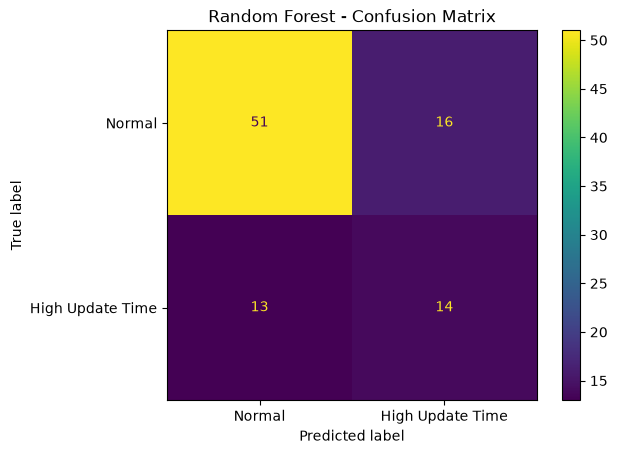

In [74]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_rf_tuned
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "High Update Time"]
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

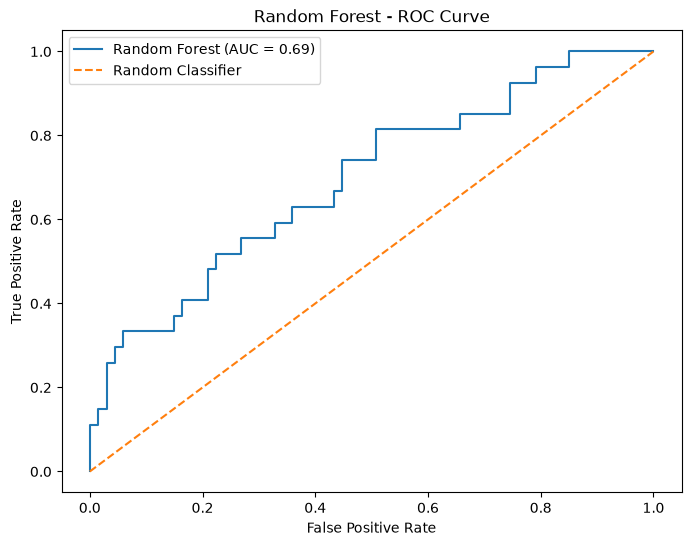

In [75]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC curve
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_rf_tuned
)

roc_auc = roc_auc_score(
    y_test,
    y_prob_rf_tuned
)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest - ROC Curve")

plt.legend()
plt.show()

In [77]:
# TF-IDF feature names
title_features = title_vectorizer.get_feature_names_out()
description_features = description_vectorizer.get_feature_names_out()

print("Title features:", len(title_features))
print("Description features:", len(description_features))

Title features: 500
Description features: 1000


In [79]:
# -----------------------------------
# GET PROCESSED FEATURE NAMES
# -----------------------------------

feature_names = preprocessor.get_feature_names_out()

print("Total feature names:", len(feature_names))

print("\nFirst 20 features:")
print(feature_names[:20])

Total feature names: 1646

First 20 features:
['title_tfidf__000' 'title_tfidf__002' 'title_tfidf__01' 'title_tfidf__02'
 'title_tfidf__027' 'title_tfidf__03' 'title_tfidf__04' 'title_tfidf__096'
 'title_tfidf__0ma01' 'title_tfidf__10' 'title_tfidf__103'
 'title_tfidf__11' 'title_tfidf__113' 'title_tfidf__118'
 'title_tfidf__123' 'title_tfidf__1257' 'title_tfidf__13'
 'title_tfidf__1432' 'title_tfidf__15' 'title_tfidf__16']


In [80]:
# -----------------------------------
# FEATURE IMPORTANCE
# -----------------------------------

feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=feature_names
)

top_features = (
    feature_importance
    .sort_values(ascending=False)
    .head(20)
)

print("Top 20 Important Features:")
print(top_features)

Top 20 Important Features:
numerical__published_year                                          0.035642
numerical__description_word_count                                  0.028798
numerical__text_word_count                                         0.028649
title_tfidf__variation                                             0.023966
numerical__text_length                                             0.021259
numerical__organisation_length                                     0.020847
numerical__description_length                                      0.020634
numerical__published_month                                         0.017093
description_tfidf__details                                         0.016789
categorical__topic_category_transport                              0.016525
numerical__title_word_count                                        0.012817
title_tfidf__issued                                                0.012808
categorical__author_organisation_Marine Management Organisati

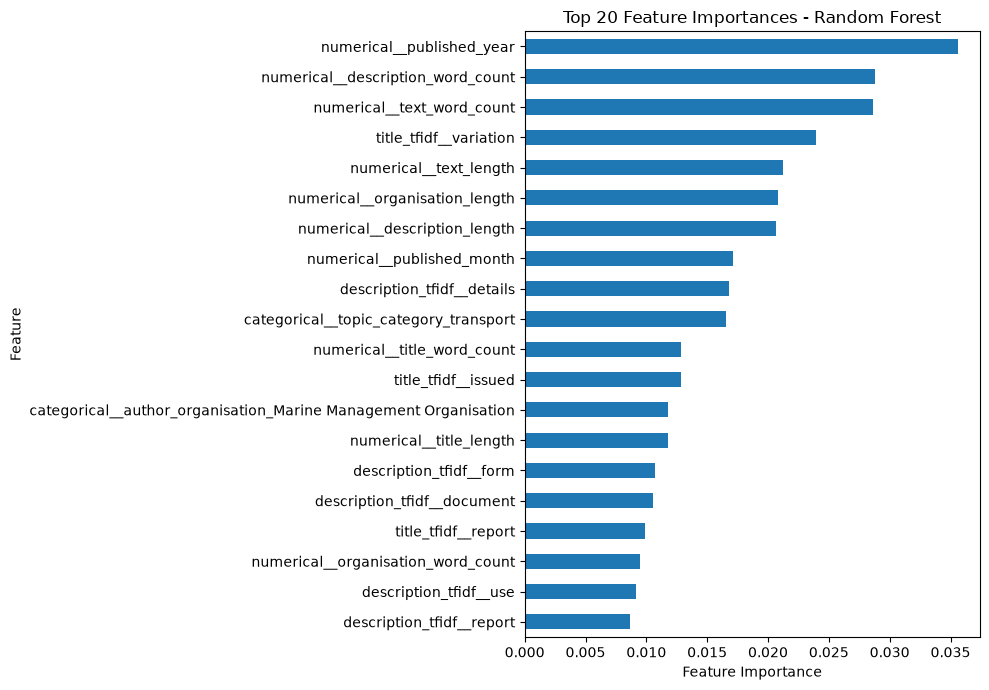

In [81]:
# -----------------------------------
# TOP 20 FEATURE IMPORTANCE PLOT
# -----------------------------------

plt.figure(figsize=(10, 7))

top_features.sort_values().plot(
    kind="barh"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances - Random Forest")

plt.tight_layout()
plt.show()

In [84]:
import joblib
from sklearn.pipeline import Pipeline

# -----------------------------------
# FINAL PIPELINE
# -----------------------------------

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_rf)
])

# -----------------------------------
# FIT FINAL PIPELINE
# -----------------------------------

final_pipeline.fit(
    X_train,
    y_train
)

# -----------------------------------
# SAVE PIPELINE
# -----------------------------------

joblib.dump(
    final_pipeline,
    "../data/govuk_final_pipeline.joblib"
)

print("Final pipeline saved successfully!")
print("../data/govuk_final_pipeline.joblib")

Final pipeline saved successfully!
../data/govuk_final_pipeline.joblib


In [85]:
import joblib
import pandas as pd

# -----------------------------------
# LOAD SAVED PIPELINE
# -----------------------------------

loaded_pipeline = joblib.load(
    "../data/govuk_final_pipeline.joblib"
)

print("Pipeline loaded successfully!")

Pipeline loaded successfully!


In [86]:
# -----------------------------------
# NEW SAMPLE
# -----------------------------------

new_data = pd.DataFrame({
    "title": [
        "Annual transport safety report and recommendations"
    ],
    "description": [
        "This report provides an assessment of transport safety performance and recommendations for future improvements."
    ],
    "author_organisation": [
        "Department for Transport"
    ],
    "published_date": [
        "2025-06-15"
    ],
    "updated_date": [
        "2025-07-20"
    ],
    "topic_url": [
        "https://www.gov.uk/transport"
    ]
})

In [87]:
print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['published_year', 'published_month', 'published_quarter', 'published_dayofweek', 'title_length', 'title_word_count', 'description_length', 'description_word_count', 'text_length', 'text_word_count', 'organisation_length', 'organisation_word_count', 'has_topic']

Categorical features:
['author_organisation', 'topic_category']


In [88]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd


class FeatureEngineeringTransformer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        X = X.copy()

        # -----------------------------
        # Make sure dates are datetime
        # -----------------------------
        X["published_date"] = pd.to_datetime(
            X["published_date"],
            errors="coerce",
            utc=True
        )

        X["updated_date"] = pd.to_datetime(
            X["updated_date"],
            errors="coerce",
            utc=True
        )

        # -----------------------------
        # Date features
        # -----------------------------
        X["published_year"] = X["published_date"].dt.year
        X["published_month"] = X["published_date"].dt.month
        X["published_quarter"] = X["published_date"].dt.quarter
        X["published_dayofweek"] = X["published_date"].dt.dayofweek

        # -----------------------------
        # Text features
        # -----------------------------
        X["title"] = X["title"].fillna("")
        X["description"] = X["description"].fillna("")

        X["title_length"] = X["title"].str.len()
        X["title_word_count"] = X["title"].str.split().str.len()

        X["description_length"] = X["description"].str.len()
        X["description_word_count"] = (
            X["description"].str.split().str.len()
        )

        X["text_length"] = (
            X["title_length"] +
            X["description_length"]
        )

        X["text_word_count"] = (
            X["title_word_count"] +
            X["description_word_count"]
        )

        # -----------------------------
        # Organisation features
        # -----------------------------
        X["author_organisation"] = (
            X["author_organisation"].fillna("")
        )

        X["organisation_length"] = (
            X["author_organisation"].str.len()
        )

        X["organisation_word_count"] = (
            X["author_organisation"].str.split().str.len()
        )

        # -----------------------------
        # Topic features
        # -----------------------------
        X["has_topic"] = (
            X["topic_url"].notna()
        ).astype(int)

        X["topic_category"] = (
            X["topic_url"]
            .fillna("")
            .str.replace(
                "https://www.gov.uk/",
                "",
                regex=False
            )
            .str.split("/")
            .str[0]
        )

        return X

In [89]:
feature_engineer = FeatureEngineeringTransformer()

X_train_fe = feature_engineer.fit_transform(X_train)

print(X_train_fe.shape)
print(X_train_fe.columns.tolist())

(374, 21)
['title', 'description', 'url', 'author_organisation', 'published_date', 'updated_date', 'topic_url', 'published_year', 'description_length', 'published_month', 'published_quarter', 'published_dayofweek', 'title_length', 'title_word_count', 'description_word_count', 'text_length', 'text_word_count', 'organisation_length', 'organisation_word_count', 'has_topic', 'topic_category']


In [90]:
from sklearn.pipeline import Pipeline
import joblib

# -----------------------------------
# FINAL END-TO-END PIPELINE
# -----------------------------------

deployment_pipeline = Pipeline([
    ("feature_engineering", FeatureEngineeringTransformer()),
    ("preprocessor", preprocessor),
    ("model", best_rf)
])

# -----------------------------------
# TRAIN
# -----------------------------------

deployment_pipeline.fit(
    X_train,
    y_train
)

print("Deployment pipeline trained successfully!")

Deployment pipeline trained successfully!


In [91]:
# Test on unseen test data

y_pred_deployment = deployment_pipeline.predict(X_test)

print("Deployment pipeline test accuracy:",
      accuracy_score(y_test, y_pred_deployment))

Deployment pipeline test accuracy: 0.6808510638297872


In [92]:
joblib.dump(
    deployment_pipeline,
    "../data/govuk_final_deployment_pipeline.joblib"
)

print("Final deployment pipeline saved successfully!")

Final deployment pipeline saved successfully!
